## Ideas for problems

### High value; long-term

- cross-source edge prediction - can we predict IntAct edges based on OmniPath? How account for overlapping data informing sources.
- can we predict perturbation effects? From a source vertex, can we predict the set of vertices that will be affected?
   - the reverse of the above: can we predict a perturbation from its effects?
- hierarchical biological representations. can we improve community detection (pathway characterization). This could involve creating graphs at varying coarseness.

   - Level 0: Individual molecular interactions (from IntAct, STRING physical)
   - Level 1: Functional modules (STRING functional, local pathway subgraphs)
   - Level 2: Pathway-level (Reactome pathways, KEGG modules)
   - Level 3: Pathway crosstalk (consensus model connections between pathways)
   - Level 4: Biological processes (GO-slim equivalent)

### Benchmarks

- how does a Napistu graph compared to a simple STRING undirected graph?
- what sources are most important for prediction?

### Easy
- community detection - can we take the consensus Reactome model and predict the original submodels?


### Random thoughts
- can GNN's learn conservation of mass? (if some substrates and products are missing, can they be predicted?)
- can we predict perturbation effects? From a source vertex, can we predict the set of vertices that will be affected?
- the reverse of the above: can we predict a perturbation from its effects?
- community detection - can we take the consensus Reactome model and predict the original submodels?
- cross-source edge prediction - can we predict IntAct edges based on OmniPath? How account for overlapping data informing sources.
- how does a Napistu graph compared to a simple STRING undirected graph?
- what sources are most important for prediction?
- filter to just STRING intearctions and compare with full graph
- predict GO category membership (hold out 20% of the vertices in each category)


In [1]:
import logging
import os

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("napistu_torch")

NAPISTU_DATA_STORE_DIR = "./.store"
NAPISTU_DATA_DIR = "./.napistu_data" # where to save data from GCS
ASSET_NAME = "human_consensus"
ASSET_VERSION = None
OVERWRITE = True

In [2]:
from napistu_torch.load.gcs import gcs_model_to_store

/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize `NapistuDataStore`

`NapistuDataStore` is a flexible, evolving, format for data and metadata management in the `napistu-torch` library. During construction it:

1. Creates (or uses an existing) `store_dir` directory and subdirectories which will be used to organize JSON metadata and serialized PyTorch `.py` checkpoints.
2. Connects to Napistu `SBML_dfs` and `NapistuGraph` pickles describing a biological pathway and its network representation.
3. Initializes a `registry.json` file in `store_dir` which tracks paths to the raw `SBML_dfs` and `NapistuGraph`s. This json will be fleshed out to include additional PyTorch-centric artifacts and their metadata.

After construction, a `NapistuDataStore` can be initialized from its `registry.json` file to load existing artifacts and register new ones.

`NapistuDataStore` can organize the following `napistu-torch`-specific artifacts:
- `NapistuData` for organizing graph's as a set of tensors and associated metadata
- `VertexTensor` for organizing vertex-level information

## `NapistuData`

`NapistuData` is a subclass of PyTorch's Geometric (*PyG*) `Data` class which inherits these standard `Data` attributes:

- `x` : vertex-level `torch.Tensor`
- `edge_index` : from-to edgelist `torch.Tensor`
- `edge_attr` : edge-level `torch.Tensor`
- `edge_weight` (optional) : 1D `torch.Tensor` containing edge weights. By convention in Napistu lower weights reflect stronger/higher belief interactions
- `y` (optional) : a Tensor containing labels used during supervised learning

`NapistuData` builds on `Data` with additional standard attributes. (Note that these are still attributes of the `Data` attributes so they are supported by Torch's fast serialization/deserialization.):

- `vertex_feature_names` (optional) : a list of attributes corresponding to the columns of `x`. These follow sklearn conventions.
- `edge_feature_names` (optional) : a list of attributes corresponding to the columns of `edge_attr`. These follow sklearn conventions.
- `ng_vertex_names` (optional) : a pd.Series vertex names based on the source `NapistuGraph` object.
- `ng_edge_names` (optional) : a pd.DataFrame of from/to edges based on the source `NapistuGraph` object.
- `name` : a name for the `NapistuData` object, used primarily for organizing artifacts in `NapistuDataStore`.
- `splitting_strategy` : a summary of how (and whether) train/test/val splits were performed.
- `labeling_manager`: a summary of the attribute used for labels and the key to map from integer labels to strings
- `**` : additional attributes can be included, for example most splitting strategies will generate a `train_mask`, `test_mask` and `val_mask`

 

In [3]:
napistu_data_store = gcs_model_to_store(
    napistu_data_dir = NAPISTU_DATA_DIR,
    store_dir = NAPISTU_DATA_STORE_DIR,
    asset_name = ASSET_NAME,
)

In [4]:
# TO DO - integrate NapistuDataStore with new configs

# 1. a config should be able to initialize a NapistuDataStore or reuse an existing one (accepts store_dir, sbml_dfs_path,
# napistu_graph_path, allow_init (create a new NapistuDataStore or reuse an existing one), overwrite (?), copy_to_store (?), as arguments)

# 2. a config should be able to specify relevant parameters for constructing a NapistuData object and this should trigger either 
# creation (+ registration) of new artifacts or reuse of existing ones from the NapistuDataStore. 

# This would then allow us to just pass a config into the lightning data loader which would then be used to construct
# the NapistuDataStore, load the data, and pass it to the model

In [5]:
#sbml_dfs = napistu_data_store.load_sbml_dfs()
#napistu_graph = napistu_data_store.load_napistu_graph()

#edge_prediction_data = construct_unsupervised_pyg_data(
#    sbml_dfs,
#    napistu_graph,
#    splitting_strategy = SPLITTING_STRATEGIES.EDGE_MASK,
#)

# napistu_data_store.save_napistu_data(edge_prediction_data)

In [6]:
import sys
import torch
from torch_geometric.nn import Node2Vec
import torch_cluster # needed for Node2Vec

from napistu_torch.ml.torch_utils import select_device

device = select_device(mps_valid=False)

In [7]:
napistu_data = napistu_data_store.load_napistu_data("edge_prediction")
# use the edge weights but invert them since by convention NapistuGraph uses low weights
# for stronger edges and Node2Vec does the opposite (selecting edges to traverse proportional to edge weight)
napistu_data.edge_weight = napistu_data.edge_weight.reciprocal()

# load comprehensive pathway assignments for validation
comprehensive_pathway_assignments = napistu_data_store.load_vertex_tensor("comprehensive_pathway_memberships")
pathway_assignments = comprehensive_pathway_assignments.align_to_napistu_data(napistu_data, inplace=False).data

# mask to use to just evaluate molecular species
species_type_mask = napistu_data.get_feature_by_name("categorical__node_type_species")

INFO:napistu_torch.napistu_data_store:Loading NapistuData from .store/napistu_data/edge_prediction.pt
INFO:napistu_torch.napistu_data_store:Loading VertexTensor from .store/vertex_tensors/comprehensive_pathway_memberships.pt


In [13]:
from napistu_torch.tasks.node2vec import get_node2vec_training_regime, get_node2vec_model, get_node2vec_training_loop
import torch
import torch.nn.functional as F
from napistu_torch.ml.torch_utils import memory_manager
import numpy as np
from napistu_torch.evaluation.pathways import calculate_pathway_similarities

model = get_node2vec_model(napistu_data, device)
loader, optimizer = get_node2vec_training_regime(model)

training_path = {}
for epoch in range(1, 20):
    loss = get_node2vec_training_loop(model, loader, optimizer, device)

    print(f"Epoch {epoch}; loss = {loss}")

    # Evaluate within-category similarity
    model.eval()
    with torch.no_grad():
        pathway_similarities = calculate_pathway_similarities(
            embedding_matrix = model.embedding.weight.data,
            pathway_assignments = pathway_assignments,
            pathway_names = comprehensive_pathway_assignments.feature_names,
            filtering_mask = species_type_mask.bool(),
        )
    model.train()

    training_path[epoch] = {
        "loss": loss,
        "pathway_similarities": pathway_similarities,
    }



Epoch 1; loss = 4.066536372438884
Epoch 2; loss = 1.6093521738120682
Epoch 3; loss = 1.1924232483593304
Epoch 4; loss = 1.0465148565079216
Epoch 5; loss = 0.9824811971631637
Epoch 6; loss = 0.9480545842545081
Epoch 7; loss = 0.9271717776370937
Epoch 8; loss = 0.9145054617378978
Epoch 9; loss = 0.9076066696028996
Epoch 10; loss = 0.9039750489942665
Epoch 11; loss = 0.9014036766266754
Epoch 12; loss = 0.899320267145135
Epoch 13; loss = 0.8978690082500862
Epoch 14; loss = 0.8971400591739611
Epoch 15; loss = 0.8968663913472675
Epoch 16; loss = 0.896782826215968
Epoch 17; loss = 0.8965105944684036
Epoch 18; loss = 0.8964274869948882
Epoch 19; loss = 0.8961486107128056


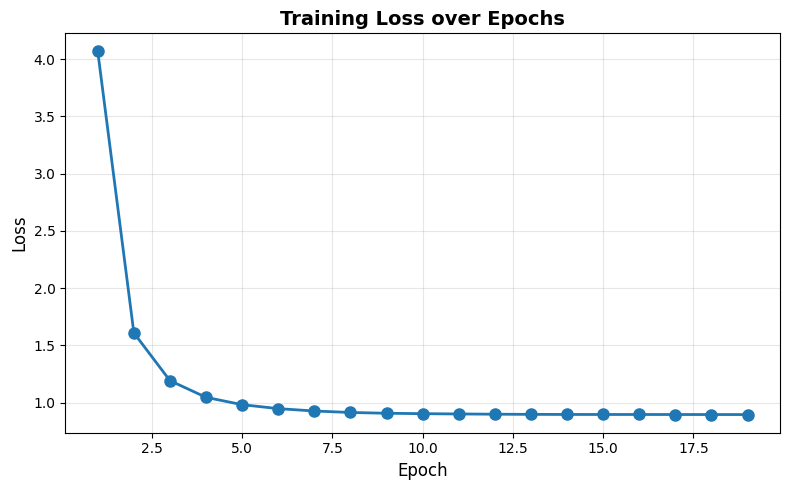

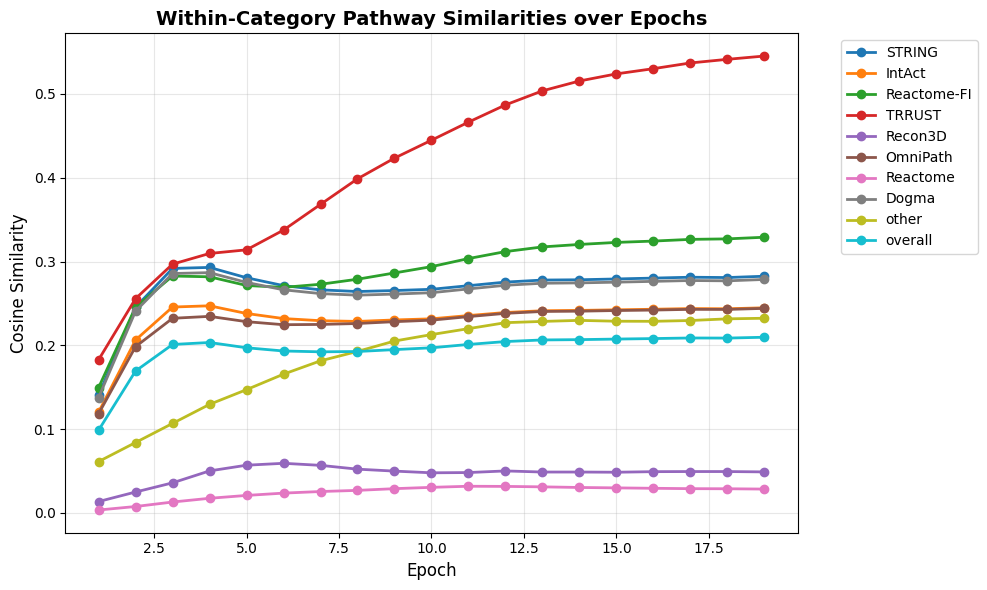

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def metrics_to_dataframes(metrics_dict):
    """
    Convert nested metrics dictionary to separate DataFrames for loss and pathway similarities.
    
    Args:
        metrics_dict: dict with structure {epoch: {'loss': float, 'pathway_similarities': dict}}
    
    Returns:
        tuple of (loss_df, pathway_sim_df)
            - loss_df: DataFrame with columns ['epoch', 'loss']
            - pathway_sim_df: DataFrame with epochs as rows and pathways as columns
    """
    # Extract loss data
    loss_data = []
    for epoch, metrics in metrics_dict.items():
        loss_data.append({'epoch': epoch, 'loss': metrics['loss']})
    loss_df = pd.DataFrame(loss_data)
    
    # Extract pathway similarities
    pathway_data = []
    for epoch, metrics in metrics_dict.items():
        row = {'epoch': epoch}
        row.update(metrics['pathway_similarities'])
        pathway_data.append(row)
    pathway_sim_df = pd.DataFrame(pathway_data)
    pathway_sim_df = pathway_sim_df.set_index('epoch')
    
    return loss_df, pathway_sim_df

def plot_loss(loss_df, figsize=(8, 5)):
    """
    Plot training loss over epochs.
    
    Args:
        loss_df: DataFrame with columns ['epoch', 'loss']
        figsize: tuple of (width, height) for the figure
    
    Returns:
        fig, ax: matplotlib figure and axes objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.plot(loss_df['epoch'], loss_df['loss'], 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training Loss over Epochs', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax


def plot_pathway_similarities(pathway_sim_df, figsize=(10, 6)):
    """
    Plot pathway similarities over epochs with separate colors for each pathway.
    
    Args:
        pathway_sim_df: DataFrame with epochs as index and pathways as columns
        figsize: tuple of (width, height) for the figure
    
    Returns:
        fig, ax: matplotlib figure and axes objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    epochs = pathway_sim_df.index
    
    # Plot each pathway with a different color
    for column in pathway_sim_df.columns:
        ax.plot(epochs, pathway_sim_df[column], 'o-', 
                label=column, linewidth=2, markersize=6)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title('Within-Category Pathway Similarities over Epochs', 
                 fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Usage:
loss_df, pathway_sim_df = metrics_to_dataframes(training_path)

# Plot loss
fig1, ax1 = plot_loss(loss_df)
plt.show()

# Plot pathway similarities
fig2, ax2 = plot_pathway_similarities(pathway_sim_df)
plt.show()

In [20]:
import re
from napistu_torch.visualization.embeddings import layout_umap

embeddings = model.embedding.weight.data
umap_layout_species = layout_umap(embeddings, filtering_mask=species_type_mask.bool(), n_neighbors = 20)

# TO DO - replace with new napistu_data method
mask = [bool(re.search("__species_type", x)) for x in napistu_data.get_vertex_feature_names()]
indices = [i for i, m in enumerate(mask) if m]
masks = napistu_data.x[:, indices]

# only look at the vertices with embedding values
masks = masks[species_type_mask.bool()]
mask_names = [x for x, m in zip(napistu_data.get_vertex_feature_names(), mask) if m]


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


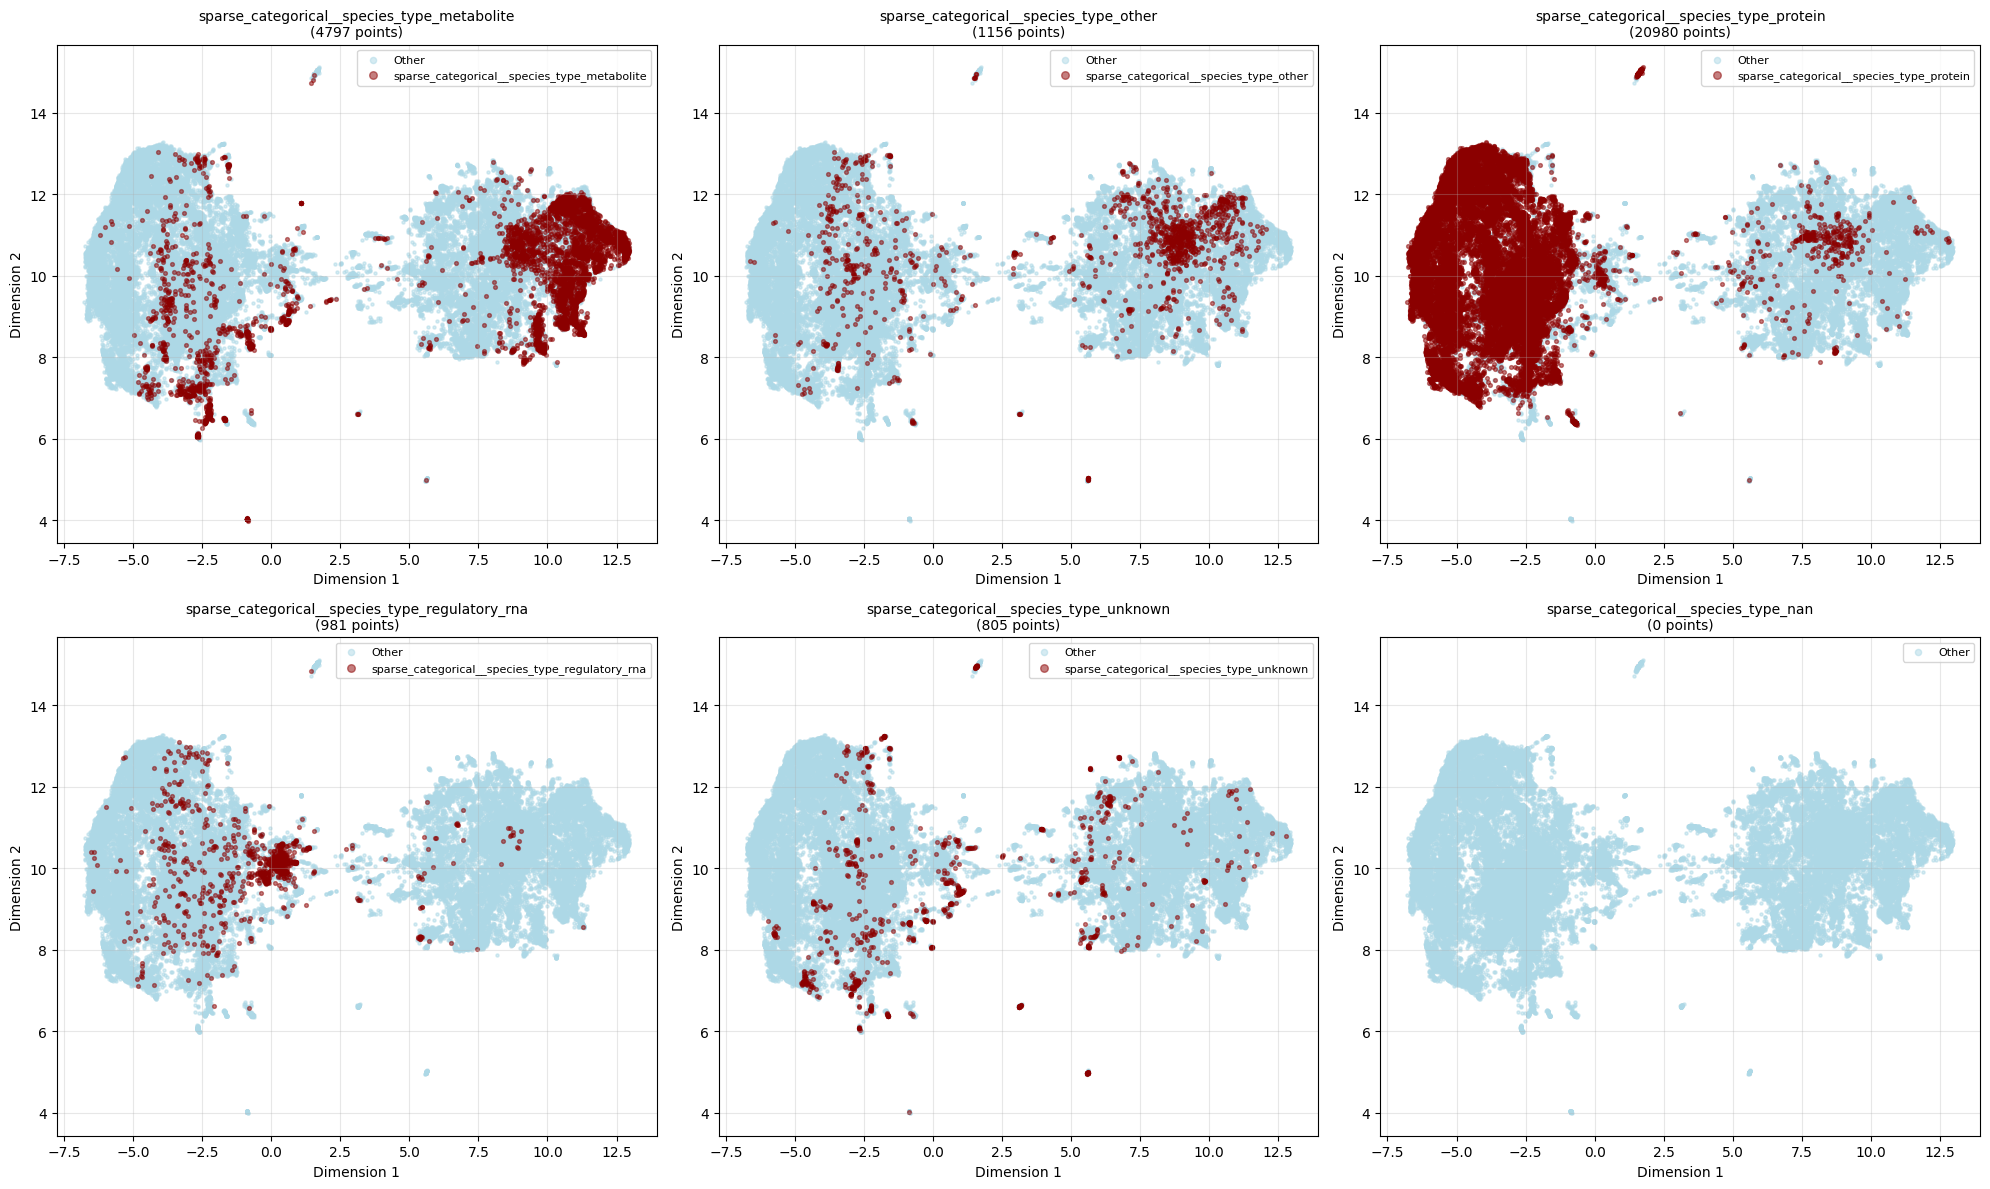

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from napistu_torch.visualization.embeddings import plot_coordinates_with_masks


# Example:
fig, axes = plot_coordinates_with_masks(
    coordinates=umap_layout_species,
    masks=masks,  # Your tensor of masks
    mask_names=mask_names,
    figsize=(20, 12),
    ncols=3,
    cmap_bg='lightblue',
    cmap_fg='darkred',
    alpha=0.5,
    s=5
)
plt.show()